In [1]:
import json
import importlib
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)

# ════════════════════════════════════════════════════════
#  Change this path to point at any *_raw.json eval file.
#  Everything below is derived from this file alone.
# ════════════════════════════════════════════════════════
EVAL_RAW_PATH = Path("eval_results/eval_gpt-5-mini_20260311_114220_raw.json")

ACCURACY_SUBCATS = {"material", "shape", "size"}
GRADED_FNS = {"efficiency.l1_dist", "structural_stability.stress_score"}
METRIC_CATEGORY_LABELS = {
    "physical_plausibility": "Physical Plausibility",
    "shape": "Shape / Geometry",
    "material": "Material",
    "size": "Size / Dimension",
    "efficiency": "Efficiency",
    "dependency": "Dependency / Ordering",
    "structural_stability": "Structural Stability",
}

# ── Load raw JSONL ──
raw_entries = []
with open(EVAL_RAW_PATH, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            raw_entries.append(json.loads(line))

# Group by run_idx → one "problem" per unique run
problems = defaultdict(list)
for entry in raw_entries:
    problems[entry["run_idx"]].append(entry)

n_problems = len(problems)
n_entries = len(raw_entries)
model = raw_entries[0].get("model_safe", "unknown") if raw_entries else "unknown"

print(f"File:     {EVAL_RAW_PATH.name}")
print(f"Model:    {model}")
print(f"Problems: {n_problems}  (entries: {n_entries})")

File:     eval_gpt-5-mini_20260311_114220_raw.json
Model:    gpt-5-mini
Problems: 723  (entries: 747)


In [2]:
# ═══════════════════════════════════════════
#  Run evaluation checks on every entry
# ═══════════════════════════════════════════

def _resolve(dotted: str):
    fq = f"eval_code.{dotted}"
    mod_name, func_name = fq.rsplit(".", 1)
    return getattr(importlib.import_module(mod_name), func_name)

def _eval_checks(coords, checks):
    results = []
    for chk in checks:
        fn_name, args = chk["fn"], chk.get("args") or {}
        cat = fn_name.split(".", 1)[0]
        try:
            v = max(0.0, min(1.0, float(_resolve(fn_name)(coords, **args))))
        except Exception:
            v = 0.0
        results.append({"fn": fn_name, "cat": cat, "ok": v})
    return results

# Evaluate every entry
for entry in raw_entries:
    entry["_results"] = _eval_checks(entry.get("coords") or [], entry.get("checks") or [])

# Aggregate per-problem (across turns): a problem passes a check category
# only if ALL turns pass ALL checks in that category.
prob_rows = []
for run_idx in sorted(problems):
    turns = problems[run_idx]
    all_results = [r for t in turns for r in t["_results"]]

    cats_present = {r["cat"] for r in all_results}
    fns_present = {r["fn"] for r in all_results}

    def _all_pass(subset):
        return all(r["ok"] >= 1.0 for r in subset) if subset else True

    acc_results = [r for r in all_results if r["cat"] in ACCURACY_SUBCATS]
    pp_results  = [r for r in all_results if r["cat"] == "physical_plausibility"]
    dep_results = [r for r in all_results if r["cat"] == "dependency"]

    graded = {}
    for r in all_results:
        if r["fn"] in GRADED_FNS:
            graded[r["fn"]] = r["ok"]

    prob_rows.append({
        "run_idx": run_idx,
        "n_turns": turns[0]["n_turns"],
        "all_results": all_results,
        "cats_present": cats_present,
        "fns_present": fns_present,
        # binary verdicts
        "accurate": _all_pass(acc_results),
        "phys_plausible": _all_pass(pp_results),
        "dep_correct": _all_pass(dep_results),
        "all_binary_correct": _all_pass(acc_results) and _all_pass(pp_results) and _all_pass(dep_results),
        "has_acc": len(acc_results) > 0,
        "has_pp": len(pp_results) > 0,
        "has_dep": len(dep_results) > 0,
        **{f"graded_{fn}": v for fn, v in graded.items()},
    })

df = pd.DataFrame(prob_rows)
print(f"Evaluated {n_problems} problems  ✓")

d:\git\mineCEraft\mineCEraft\eval_code\utils\stress.py:264: RuntimeWarning: overflow encountered in matmul
  return (F @ S) + (dprime @ Finv.T) * (2.0 * J * eta)
d:\git\mineCEraft\mineCEraft\eval_code\utils\stress.py:264: RuntimeWarning: invalid value encountered in matmul
  return (F @ S) + (dprime @ Finv.T) * (2.0 * J * eta)
d:\git\mineCEraft\mineCEraft\eval_code\utils\stress.py:255: RuntimeWarning: invalid value encountered in multiply
  S = lame_lam * trE * I + 2.0 * lame_mu * E
d:\git\mineCEraft\mineCEraft\eval_code\utils\stress.py:255: RuntimeWarning: overflow encountered in multiply
  S = lame_lam * trE * I + 2.0 * lame_mu * E
c:\Users\sewoo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\linalg\linalg.py:2180: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
d:\git\mineCEraft\mineCEraft\eval_code\utils\stress.py:264: RuntimeWarning: invalid value encountered in add
  return (F @ S) + (dprime @ Finv.T) * (2.0 * J * eta)


d:\git\mineCEraft\mineCEraft\eval_code\utils\stress.py:264: RuntimeWarning: invalid value encountered in multiply
  return (F @ S) + (dprime @ Finv.T) * (2.0 * J * eta)


Evaluated 723 problems  ✓


## Table 1 — Benchmark Description
How many of the N problems include checks from each metric category / check function.  
All counts are out of **N problems** (one prompt variant = one problem).

In [3]:
# ── 1a: Per metric-category ──
cat_counts = Counter()
for _, row in df.iterrows():
    for c in row["cats_present"]:
        cat_counts[c] += 1

desc_a = []
for cat in sorted(cat_counts, key=lambda c: -cat_counts[c]):
    n = cat_counts[cat]
    desc_a.append({
        "Metric Category": METRIC_CATEGORY_LABELS.get(cat, cat),
        "#Problems": n,
        "% of Total": f"{n / n_problems * 100:.1f}%",
    })
desc_a.append({"Metric Category": f"**Total problems**", "#Problems": n_problems, "% of Total": ""})

display(Markdown(f"### Metric-Category Coverage ({n_problems} problems)"))
display(pd.DataFrame(desc_a).style.hide(axis="index"))

# ── 1b: Per check-function ──
fn_counts = Counter()
for _, row in df.iterrows():
    for fn in row["fns_present"]:
        fn_counts[fn] += 1

desc_b = []
for fn, n in fn_counts.most_common():
    cat = fn.split(".", 1)[0]
    desc_b.append({
        "Metric Category": METRIC_CATEGORY_LABELS.get(cat, cat),
        "Check Function": fn,
        "#Problems": n,
        "% of Total": f"{n / n_problems * 100:.1f}%",
    })

display(Markdown(f"### Check-Function Frequency ({n_problems} problems)"))
display(pd.DataFrame(desc_b).style.hide(axis="index"))

### Metric-Category Coverage (723 problems)

Metric Category,#Problems,% of Total
Physical Plausibility,723,100.0%
Shape / Geometry,563,77.9%
Material,455,62.9%
Size / Dimension,369,51.0%
Dependency / Ordering,156,21.6%
Efficiency,112,15.5%
Structural Stability,21,2.9%
**Total problems**,723,


### Check-Function Frequency (723 problems)

Metric Category,Check Function,#Problems,% of Total
Physical Plausibility,physical_plausibility.is_ground_connected,723,100.0%
Shape / Geometry,shape.cluster_count_at_y_is,281,38.9%
Material,material.is_block_cnt_equal_to,196,27.1%
Size / Dimension,size.max_y_is_geq,188,26.0%
Shape / Geometry,shape.are_doors_passable,186,25.7%
Shape / Geometry,shape.has_rooms,186,25.7%
Material,material.is_all_material_equal_to,160,22.1%
Dependency / Ordering,dependency.material_sequence_order,156,21.6%
Shape / Geometry,shape.clusters_at_y_have_min_span,120,16.6%
Material,material.is_block_cnt_geq,117,16.2%


## Table 2 — Binary Metrics
**Overall Accuracy**: all binary checks that apply to a problem must pass (accuracy ∩ physical plausibility ∩ dependency).  
Subcategories shown indented below: material+shape+size accuracy, physical plausibility, and dependency.

In [4]:
def _pct(n, total):
    return f"{n / total * 100:.1f}%" if total > 0 else "–"

# ── Per-subcategory accuracy (material / shape / size individually) ──
subcat_rows = []
for subcat in sorted(ACCURACY_SUBCATS):
    mask = df["cats_present"].apply(lambda s: subcat in s)
    n_items = int(mask.sum())
    if n_items == 0:
        continue
    sub_results = []
    for _, row in df[mask].iterrows():
        checks = [r for r in row["all_results"] if r["cat"] == subcat]
        sub_results.append(all(r["ok"] >= 1.0 for r in checks))
    n_pass = sum(sub_results)
    subcat_rows.append({
        "Metric": f"  {METRIC_CATEGORY_LABELS.get(subcat, subcat)}",
        "#Problems": n_items,
        "#Correct": n_pass,
        "Accuracy": _pct(n_pass, n_items),
    })

# ── Accuracy overall ──
n_acc = int(df["has_acc"].sum())
n_acc_pass = int(df.loc[df["has_acc"], "accurate"].sum())

# ── Physical plausibility ──
n_pp = int(df["has_pp"].sum())
n_pp_pass = int(df.loc[df["has_pp"], "phys_plausible"].sum())

# ── Dependency ──
n_dep = int(df["has_dep"].sum())
n_dep_pass = int(df.loc[df["has_dep"], "dep_correct"].sum())

# ── All correct ──
n_all_pass = int(df["all_binary_correct"].sum())

table2 = pd.DataFrame([
    {"Metric": "**Overall Accuracy (acc ∩ pp ∩ dep)**", "#Problems": n_problems, "#Correct": n_all_pass, "Accuracy": _pct(n_all_pass, n_problems)},
    {"Metric": "  Accuracy (material ∩ shape ∩ size)", "#Problems": n_acc, "#Correct": n_acc_pass, "Accuracy": _pct(n_acc_pass, n_acc)},
    *subcat_rows,
    {"Metric": "  Physical Plausibility",              "#Problems": n_pp,  "#Correct": n_pp_pass,  "Accuracy": _pct(n_pp_pass, n_pp)},
    {"Metric": "  Dependency",                         "#Problems": n_dep, "#Correct": n_dep_pass, "Accuracy": _pct(n_dep_pass, n_dep)},
])

display(Markdown(f"### Binary Metrics ({n_problems} problems)"))
display(table2.style.hide(axis="index"))

### Binary Metrics (723 problems)

Metric,#Problems,#Correct,Accuracy
**Overall Accuracy (acc ∩ pp ∩ dep)**,723,286,39.6%
Accuracy (material ∩ shape ∩ size),699,317,45.4%
Material,455,410,90.1%
Shape / Geometry,563,213,37.8%
Size / Dimension,369,284,77.0%
Physical Plausibility,723,490,67.8%
Dependency,156,153,98.1%


## Table 3 — Graded Metrics
Efficiency (L1 path ratio) and structural stability (stress score), each ∈ [0, 1].  
Two views: **all** problems vs **accurate-only** (where all accuracy checks pass).

In [5]:
GRADED_LABELS = {
    "efficiency.l1_dist": "Efficiency (L1 path ratio)",
    "structural_stability.stress_score": "Structural Stability (stress)",
}

table3_rows = []
for fn_name, label in GRADED_LABELS.items():
    col = f"graded_{fn_name}"
    if col not in df.columns:
        continue

    has = df[col].notna()
    n_all = int(has.sum())
    if n_all == 0:
        continue

    mean_all = df.loc[has, col].mean()
    acc_mask = has & df["accurate"]
    n_acc = int(acc_mask.sum())
    mean_acc = df.loc[acc_mask, col].mean() if n_acc > 0 else float("nan")

    table3_rows.append({
        "Metric": label,
        "#Problems (all)": n_all,
        "Mean (all)": f"{mean_all:.3f}",
        "#Problems (accurate)": n_acc,
        "Mean (accurate only)": f"{mean_acc:.3f}" if n_acc > 0 else "–",
    })

if table3_rows:
    display(Markdown("### Graded Metrics"))
    display(pd.DataFrame(table3_rows).style.hide(axis="index"))
else:
    display(Markdown("*No graded metrics (efficiency / structural stability) in this eval file.*"))

### Graded Metrics

Metric,#Problems (all),Mean (all),#Problems (accurate),Mean (accurate only)
Efficiency (L1 path ratio),112,0.556,110,0.551
Structural Stability (stress),21,0.507,7,0.597


## Table 4 — Per-Check Function Results
Pass rate for every individual check function (binary: ≥ 1.0 = pass).  
Graded functions also show mean score.

In [6]:
# Flatten all results
flat = []
for _, row in df.iterrows():
    for r in row["all_results"]:
        flat.append({**r, "run_idx": row["run_idx"], "accurate": row["accurate"]})
df_flat = pd.DataFrame(flat)

detail_rows = []
for fn_name, grp in df_flat.groupby("fn"):
    cat = grp["cat"].iloc[0]
    n = len(grp)
    n_pass = int((grp["ok"] >= 1.0).sum())
    row = {
        "Metric Category": METRIC_CATEGORY_LABELS.get(cat, cat),
        "Check Function": fn_name,
        "#Problems": n,
        "#Pass": n_pass,
        "Pass Rate": _pct(n_pass, n),
    }
    if fn_name in GRADED_FNS:
        row["Mean Score"] = f"{grp['ok'].mean():.3f}"
        acc_grp = grp[grp["accurate"]]
        row["Mean (acc only)"] = f"{acc_grp['ok'].mean():.3f}" if len(acc_grp) > 0 else "–"
    else:
        row["Mean Score"] = "–"
        row["Mean (acc only)"] = "–"
    detail_rows.append(row)

df_detail = pd.DataFrame(detail_rows).sort_values(
    ["Metric Category", "Check Function"]
).reset_index(drop=True)

display(Markdown(f"### Per-Check Function Detail ({n_problems} problems)"))
display(df_detail.style.hide(axis="index"))

### Per-Check Function Detail (723 problems)

Metric Category,Check Function,#Problems,#Pass,Pass Rate,Mean Score,Mean (acc only)
Dependency / Ordering,dependency.material_sequence_order,156,153,98.1%,–,–
Efficiency,efficiency.l1_dist,112,1,0.9%,0.556,0.551
Material,material.is_all_material_equal_to,160,158,98.8%,–,–
Material,material.is_block_cnt_equal_to,196,182,92.9%,–,–
Material,material.is_block_cnt_geq,117,113,96.6%,–,–
Material,material.is_block_cnt_larger_than,75,60,80.0%,–,–
Material,material.is_block_cnt_leq,12,10,83.3%,–,–
Material,material.is_corner_material_equal_to,21,11,52.4%,–,–
Material,material.is_highest_block_material_equal_to,21,21,100.0%,–,–
Material,material.is_max_x_material_equal_to,21,20,95.2%,–,–


## Figure — Multi-Turn Accuracy by Turn
For problems with more than one turn (revisions), how does accuracy change across successive turns?  
One bar chart per distinct `n_turns` value found in the data.

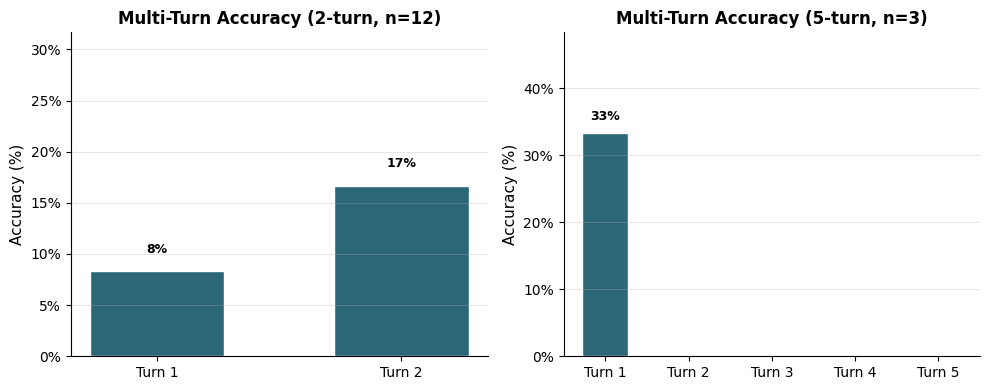

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

display(Markdown(
    "## Figure — Multi-Turn Accuracy by Turn\n"
    "For problems with more than one turn (revisions), how does accuracy change across successive turns?  \n"
    "One bar chart per distinct `n_turns` value found in the data."
))

BAR_COLOR = "#2b6777"

# ── Gather per-turn results for multi-turn problems ──
multi_turn_entries = [e for e in raw_entries if e["n_turns"] > 1]

if not multi_turn_entries:
    display(Markdown("*No multi-turn problems in this eval file.*"))
else:
    # Group by (n_turns, run_idx, turn_idx)
    mt_data = defaultdict(list)  # n_turns → list of (run_idx, turn_idx, results)
    for entry in multi_turn_entries:
        mt_data[entry["n_turns"]].append({
            "run_idx": entry["run_idx"],
            "turn_idx": entry["turn_idx"],
            "results": entry["_results"],
        })

    distinct_n_turns = sorted(mt_data.keys())
    n_charts = len(distinct_n_turns)
    fig, axes = plt.subplots(1, n_charts, figsize=(5 * n_charts, 4), squeeze=False)

    for col_idx, nt in enumerate(distinct_n_turns):
        ax = axes[0, col_idx]
        entries_for_nt = mt_data[nt]

        # Group by run_idx
        runs = defaultdict(dict)  # run_idx → {turn_idx: results}
        for e in entries_for_nt:
            runs[e["run_idx"]][e["turn_idx"]] = e["results"]

        n_runs = len(runs)
        turn_labels = [f"Turn {t}" for t in range(1, nt + 1)]
        accuracies = []

        for t in range(1, nt + 1):
            n_pass = 0
            n_total = 0
            for run_idx, turn_dict in runs.items():
                if t not in turn_dict:
                    continue
                n_total += 1
                checks = turn_dict[t]
                if all(r["ok"] >= 1.0 for r in checks):
                    n_pass += 1
            accuracies.append(n_pass / n_total * 100 if n_total > 0 else 0)

        x = np.arange(len(turn_labels))
        bars = ax.bar(x, accuracies, color=BAR_COLOR, width=0.55, edgecolor="white")

        for bar, acc in zip(bars, accuracies):
            if acc > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                        f"{acc:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(turn_labels, fontsize=10)
        ax.set_ylabel("Accuracy (%)", fontsize=11)
        ax.set_title(f"Multi-Turn Accuracy ({nt}-turn, n={n_runs})", fontsize=12, fontweight="bold")
        ax.set_ylim(0, min(max(accuracies) + 15, 105))
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()
    plt.show()